# Exploring BC5CDR Dataset (Disease & Nutrient)

This notebook explores the preprocessed BC5CDR dataset in BIO format, which is used to train the NER model to detect **DISEASE** and **NUTRIENT** entities. We will extract the Top 20 most frequent entities for both classes and visualize them.

In [1]:
import os
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Set path to the bc5cdr_bio.jsonl file
data_path = '../../data/en/bc5cdr_bio.jsonl'
if not os.path.exists(data_path):
    data_path = 'data/en/bc5cdr_bio.jsonl'

print(f"Loading data from: {os.path.abspath(data_path)}")

Loading data from: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\data\en\bc5cdr_bio.jsonl


In [2]:
# Load rows
rows = []
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

print(f"Total sentences/rows in BC5CDR: {len(rows)}")

Total sentences/rows in BC5CDR: 16423


## 1. Statistics on Tokens and Labels

In [3]:
total_tokens = 0
label_counter = Counter()

for row in rows:
    total_tokens += len(row['tokens'])
    label_counter.update(row['labels'])

print(f"Total tokens: {total_tokens}")
print("\nLabel distribution:")
for label, count in label_counter.most_common():
    percentage = (count / total_tokens) * 100
    print(f"  {label:<12}: {count:>8} ({percentage:.2f}%)")

Total tokens: 334598

Label distribution:
  O           :   296893 (88.73%)
  B-NUTRIENT  :    15935 (4.76%)
  B-DISEASE   :    12850 (3.84%)
  I-DISEASE   :     7410 (2.21%)
  I-NUTRIENT  :     1510 (0.45%)


## 2. Extracting Unique Entities (Diseases & Nutrients)

In [4]:
def extract_entities(rows, ent_type):
    entities = []
    for row in rows:
        tokens = row['tokens']
        labels = row['labels']
        current_ent = []
        for t, l in zip(tokens, labels):
            if l == f"B-{ent_type}":
                if current_ent:
                    entities.append(" ".join(current_ent).lower())
                current_ent = [t]
            elif l == f"I-{ent_type}":
                if current_ent:
                    current_ent.append(t)
            else:
                if current_ent:
                    entities.append(" ".join(current_ent).lower())
                    current_ent = []
        if current_ent:
            entities.append(" ".join(current_ent).lower())
    return entities

diseases = extract_entities(rows, 'DISEASE')
nutrients = extract_entities(rows, 'NUTRIENT')

print(f"Total extracted DISEASE mentions: {len(diseases)} (Unique: {len(set(diseases))})")
print(f"Total extracted NUTRIENT mentions (Chemicals): {len(nutrients)} (Unique: {len(set(nutrients))})")

Total extracted DISEASE mentions: 12850 (Unique: 2920)
Total extracted NUTRIENT mentions (Chemicals): 15935 (Unique: 2144)


## 3. Top 20 Most Mentioned Diseases and Nutrients

In [5]:
top_20_diseases = Counter(diseases).most_common(20)
print("Top 20 Disease Mentions:")
for idx, (d, c) in enumerate(top_20_diseases):
    print(f"  {idx+1:02d}. {d:<35} : {c:>5} times")

top_20_nutrients = Counter(nutrients).most_common(20)
print("\nTop 20 Nutrient/Chemical Mentions:")
for idx, (n, c) in enumerate(top_20_nutrients):
    print(f"  {idx+1:02d}. {n:<35} : {c:>5} times")

Top 20 Disease Mentions:
  01. seizures                            :   246 times
  02. toxicity                            :   200 times
  03. hypotension                         :   187 times
  04. pain                                :   177 times
  05. hypertension                        :   157 times
  06. seizure                             :   118 times
  07. cardiotoxicity                      :   101 times
  08. proteinuria                         :    98 times
  09. nephrotoxicity                      :    92 times
  10. bradycardia                         :    89 times
  11. catalepsy                           :    86 times
  12. parkinson's disease                 :    83 times
  13. myocardial infarction               :    80 times
  14. nephropathy                         :    71 times
  15. neurotoxicity                       :    70 times
  16. anemia                              :    69 times
  17. thrombocytopenia                    :    64 times
  18. convulsions      

## 4. Visualizations

C:\Users\dongb\AppData\Local\Temp\ipykernel_24480\540891155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(d_counts), y=list(d_names), palette="Reds_r")


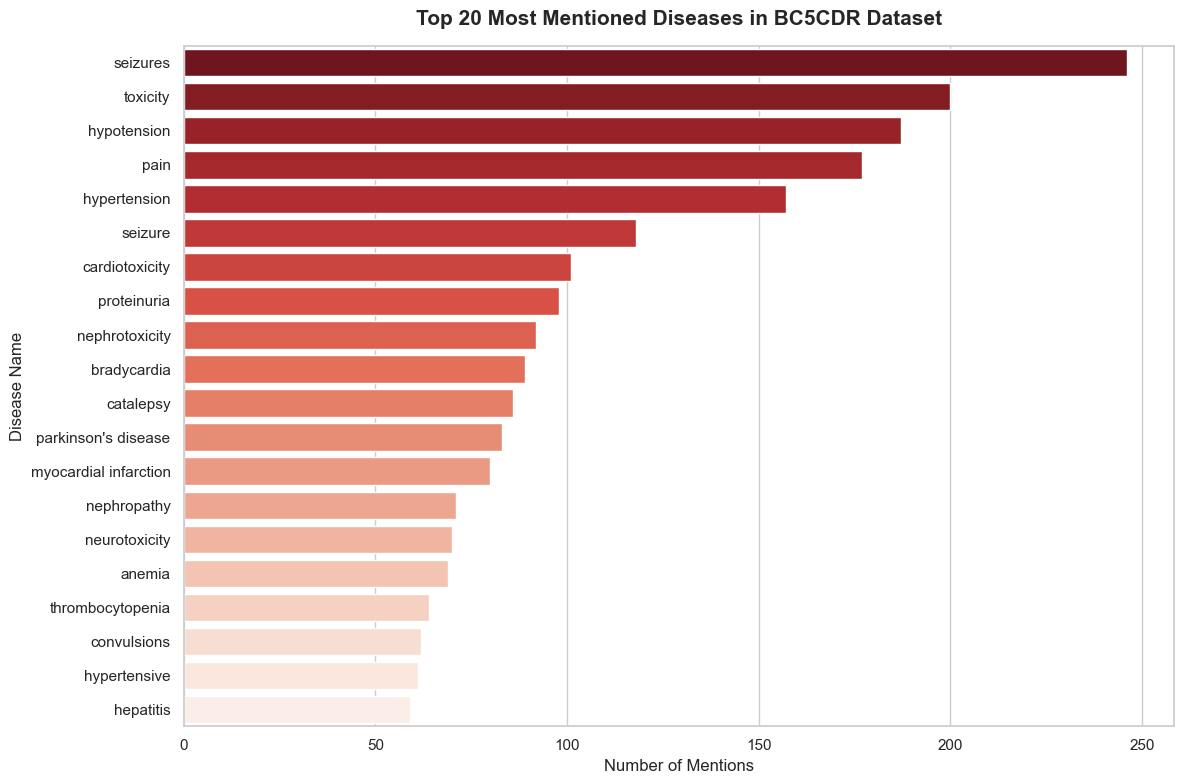

C:\Users\dongb\AppData\Local\Temp\ipykernel_24480\540891155.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(n_counts), y=list(n_names), palette="Blues_r")


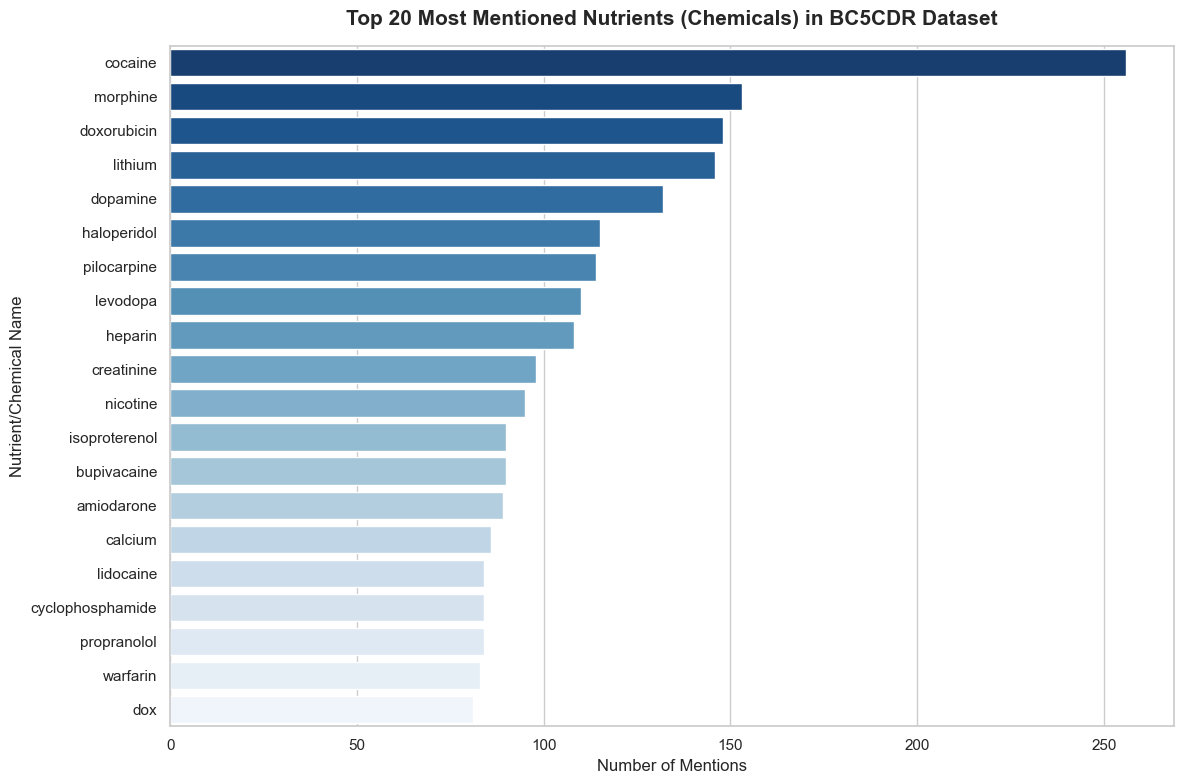

In [6]:
# Set visualization theme
sns.set_theme(style="whitegrid")

# 1. Plot Top 20 Diseases
d_names, d_counts = zip(*top_20_diseases)
plt.figure(figsize=(12, 8))
sns.barplot(x=list(d_counts), y=list(d_names), palette="Reds_r")
plt.title("Top 20 Most Mentioned Diseases in BC5CDR Dataset", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of Mentions", fontsize=12)
plt.ylabel("Disease Name", fontsize=12)
plt.tight_layout()
plt.show()

# 2. Plot Top 20 Nutrients/Chemicals
n_names, n_counts = zip(*top_20_nutrients)
plt.figure(figsize=(12, 8))
sns.barplot(x=list(n_counts), y=list(n_names), palette="Blues_r")
plt.title("Top 20 Most Mentioned Nutrients (Chemicals) in BC5CDR Dataset", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of Mentions", fontsize=12)
plt.ylabel("Nutrient/Chemical Name", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Sample Sentences

In [7]:
print("Sample Sentences from BC5CDR:")
for idx, row in enumerate(rows[:5]):
    print(f"\n--- Sentence #{idx + 1} ---")
    formatted = []
    for t, l in zip(row['tokens'], row['labels']):
        if l != 'O':
            formatted.append(f"{t}[{l}]")
        else:
            formatted.append(t)
    print(" ".join(formatted))

Sample Sentences from BC5CDR:

--- Sentence #1 ---
Naloxone[B-NUTRIENT] reverses the antihypertensive effect of clonidine[B-NUTRIENT] .

--- Sentence #2 ---
In unanesthetized , spontaneously hypertensive[B-DISEASE] rats the decrease in blood pressure and heart rate produced by intravenous clonidine[B-NUTRIENT] , 5 to 20 micrograms / kg , was inhibited or reversed by nalozone[B-NUTRIENT] , 0 .

--- Sentence #3 ---
2 to 2 mg / kg .

--- Sentence #4 ---
The hypotensive[B-DISEASE] effect of 100 mg / kg alpha-methyldopa[B-NUTRIENT] was also partially reversed by naloxone[B-NUTRIENT] .

--- Sentence #5 ---
Naloxone[B-NUTRIENT] alone did not affect either blood pressure or heart rate .
